# CranioVision — Model Comparison Report

Side-by-side analysis of training dynamics and test-set performance across the three CranioVision architectures.

**What this notebook shows:**
1. Training loss curves — convergence speed, stability
2. Validation Dice curves — peak performance, best epoch
3. Per-class Dice breakdown — where each model shines
4. BraTS region Dice (WT, TC, ET) — the clinical standard
5. Summary table for the project report

**Data source:** `outputs/*_history.json` files saved during training.

Missing models are gracefully skipped — the notebook adapts to whatever histories you have.

## 1. Setup

In [1]:
import sys
import json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from src.cranovision.config import OUTPUTS_DIR, CLASS_NAMES

# Consistent colors — same across all figures
MODEL_COLORS = {
    'attention_unet': '#FF6B35',
    'swin_unetr'    : '#4ECDC4',
    'nnunet'        : '#9B59B6',
}
MODEL_DISPLAY = {
    'attention_unet': 'Attention U-Net',
    'swin_unetr'    : 'SwinUNETR',
    'nnunet'        : 'nnU-Net (DynUNet)',
}

print('✅ Setup ok')

✅ Setup ok


## 2. Load whichever histories are available

In [2]:
histories = {}
for name in ['attention_unet', 'swin_unetr', 'nnunet']:
    path = OUTPUTS_DIR / f'{name}_history.json'
    if path.exists():
        try:
            with open(path, 'r') as f:
                histories[name] = json.load(f)
            print(f'✓ Loaded {MODEL_DISPLAY[name]:<20} — best epoch {histories[name].get("best_epoch", "?"):>3} '
                  f'| best Dice {histories[name].get("best_dice", 0):.4f}')
        except Exception as e:
            print(f'⚠ Could not load {path}: {e}')
    else:
        print(f'○ Skipped {MODEL_DISPLAY[name]:<20} — no history JSON at {path.name}')

print(f'\nHistories ready for {len(histories)} model(s): {list(histories.keys())}')

✓ Loaded Attention U-Net      — best epoch  35 | best Dice 0.7642
✓ Loaded SwinUNETR            — best epoch  75 | best Dice 0.8219
✓ Loaded nnU-Net (DynUNet)    — best epoch  80 | best Dice 0.7562

Histories ready for 3 model(s): ['attention_unet', 'swin_unetr', 'nnunet']


## 3. Training loss curves — convergence comparison

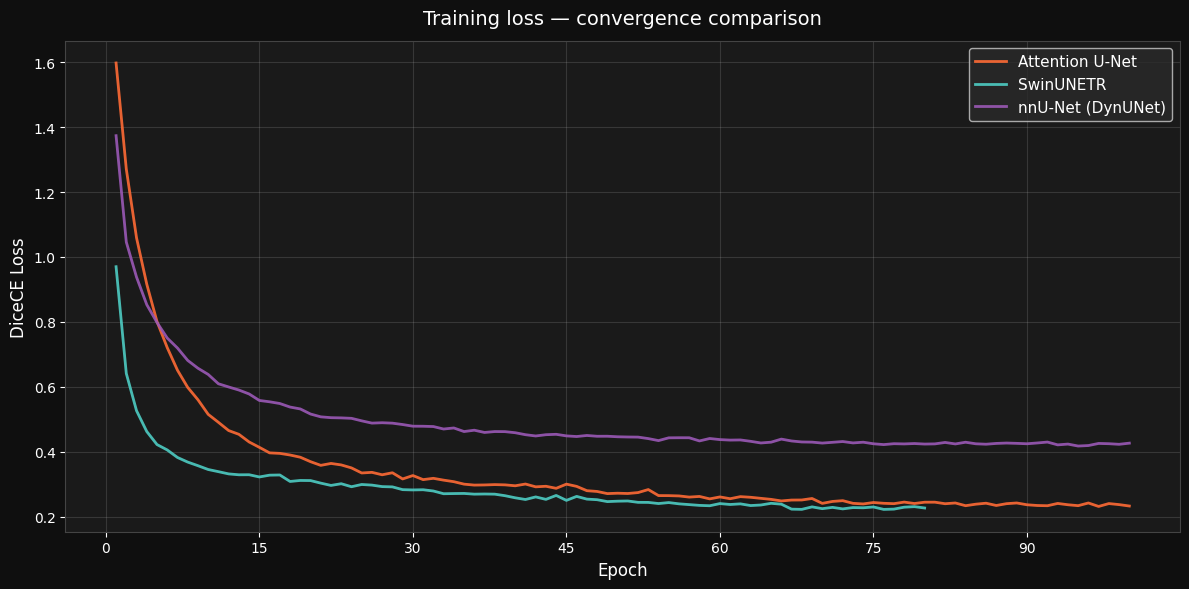

In [3]:
if not histories:
    print('No histories to plot. Run at least one training first.')
else:
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('#0f0f0f')
    ax.set_facecolor('#1a1a1a')

    for name, hist in histories.items():
        losses = hist['train_loss']
        epochs = range(1, len(losses) + 1)
        ax.plot(epochs, losses,
                color=MODEL_COLORS[name], linewidth=2,
                label=MODEL_DISPLAY[name], alpha=0.9)

    ax.set_xlabel('Epoch', color='white', fontsize=12)
    ax.set_ylabel('DiceCE Loss', color='white', fontsize=12)
    ax.set_title('Training loss — convergence comparison',
                  color='white', fontsize=14, pad=12)
    ax.tick_params(colors='white')
    ax.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=11, loc='upper right')
    ax.grid(alpha=0.2)
    for s in ax.spines.values():
        s.set_edgecolor('#444')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'comparison_loss.png', dpi=150,
                 bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()

## 4. Validation Dice curves — peak-performance comparison

The key figure. Shows which model peaks highest and when.

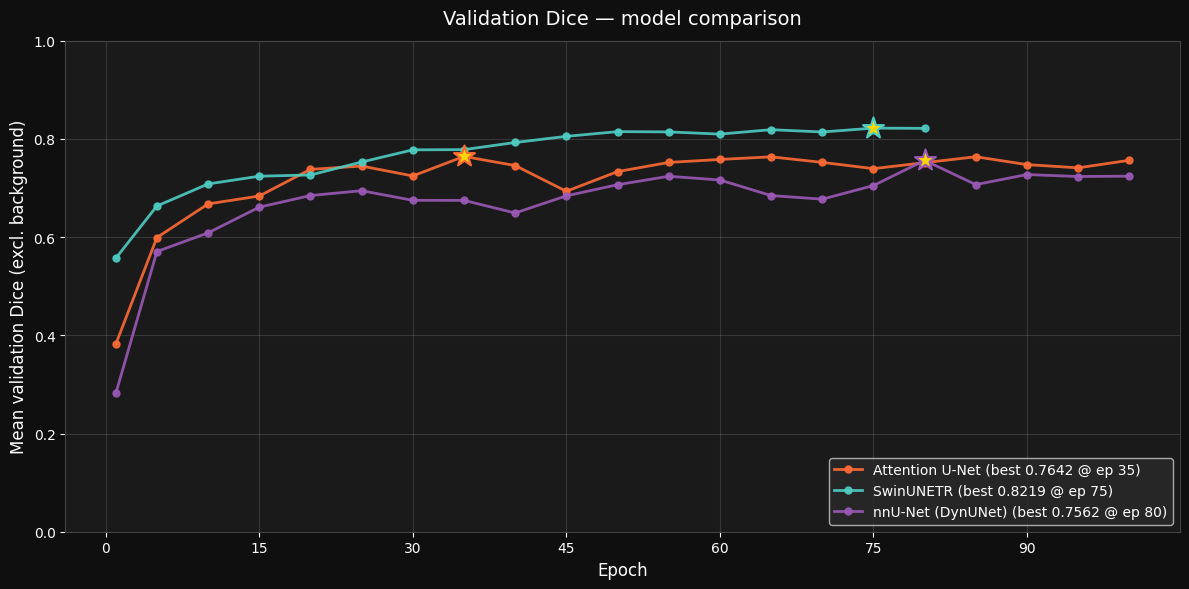

In [4]:
if not histories:
    print('No histories to plot.')
else:
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('#0f0f0f')
    ax.set_facecolor('#1a1a1a')

    for name, hist in histories.items():
        val_epochs = hist['val_epochs']
        val_dice   = hist['val_dice']
        ax.plot(val_epochs, val_dice,
                color=MODEL_COLORS[name], linewidth=2, marker='o', markersize=5,
                label=f"{MODEL_DISPLAY[name]} (best {hist['best_dice']:.4f} @ ep {hist['best_epoch']})",
                alpha=0.9)
        # Mark best point with a star
        best_idx = val_dice.index(hist['best_dice']) if hist['best_dice'] in val_dice else None
        if best_idx is not None:
            ax.scatter([val_epochs[best_idx]], [hist['best_dice']],
                        color='#FFD700', s=250, marker='*', zorder=10,
                        edgecolors=MODEL_COLORS[name], linewidths=1.5)

    ax.set_xlabel('Epoch', color='white', fontsize=12)
    ax.set_ylabel('Mean validation Dice (excl. background)', color='white', fontsize=12)
    ax.set_title('Validation Dice — model comparison',
                  color='white', fontsize=14, pad=12)
    ax.tick_params(colors='white')
    ax.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=10, loc='lower right')
    ax.grid(alpha=0.2)
    ax.set_ylim(0, 1)
    for s in ax.spines.values():
        s.set_edgecolor('#444')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'comparison_dice.png', dpi=150,
                 bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()

## 5. Test-set results — load from the per-model JSON reports

In [5]:
test_results = {}
for name in ['attention_unet', 'swin_unetr', 'nnunet']:
    path = OUTPUTS_DIR / f'{name}_test_results.json'
    if path.exists():
        with open(path, 'r') as f:
            test_results[name] = json.load(f)
        print(f'✓ Loaded test results for {MODEL_DISPLAY[name]}')
    else:
        print(f'○ No test results yet for {MODEL_DISPLAY[name]} — run inference notebook first')

print(f'\nTest results available: {len(test_results)}')

✓ Loaded test results for Attention U-Net
○ No test results yet for SwinUNETR — run inference notebook first
✓ Loaded test results for nnU-Net (DynUNet)

Test results available: 2


## 6. Per-class Dice bar chart

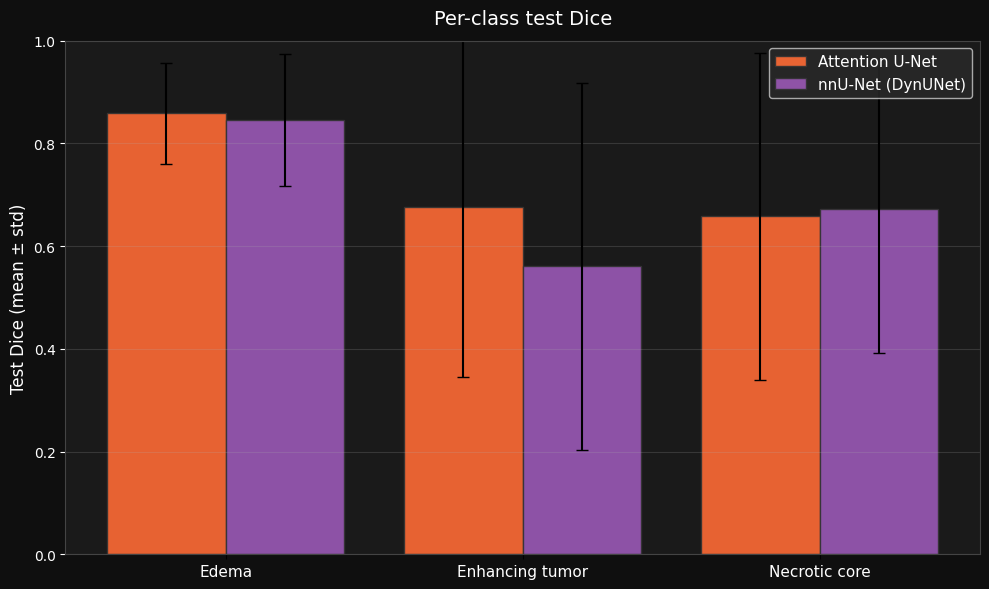

In [6]:
if not test_results:
    print('No test results to plot. Run inference notebook first.')
else:
    classes = ['Edema', 'Enhancing tumor', 'Necrotic core']
    n_models = len(test_results)
    x = np.arange(len(classes))
    bar_width = 0.8 / n_models

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#0f0f0f')
    ax.set_facecolor('#1a1a1a')

    for i, (name, res) in enumerate(test_results.items()):
        values = [res['per_class_mean'].get(c, 0) for c in classes]
        errors = [res['per_class_std'].get(c, 0)  for c in classes]
        offset = (i - n_models / 2 + 0.5) * bar_width
        ax.bar(x + offset, values, bar_width,
                yerr=errors, capsize=4,
                color=MODEL_COLORS[name],
                label=MODEL_DISPLAY[name],
                alpha=0.9, edgecolor='#333')

    ax.set_xticks(x)
    ax.set_xticklabels(classes, color='white', fontsize=11)
    ax.set_ylabel('Test Dice (mean ± std)', color='white', fontsize=12)
    ax.set_title('Per-class test Dice',
                  color='white', fontsize=14, pad=12)
    ax.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=11)
    ax.tick_params(axis='y', colors='white')
    ax.grid(alpha=0.2, axis='y')
    ax.set_ylim(0, 1)
    for s in ax.spines.values():
        s.set_edgecolor('#444')

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'comparison_per_class.png', dpi=150,
                 bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()

## 7. BraTS region Dice comparison (WT, TC, ET)

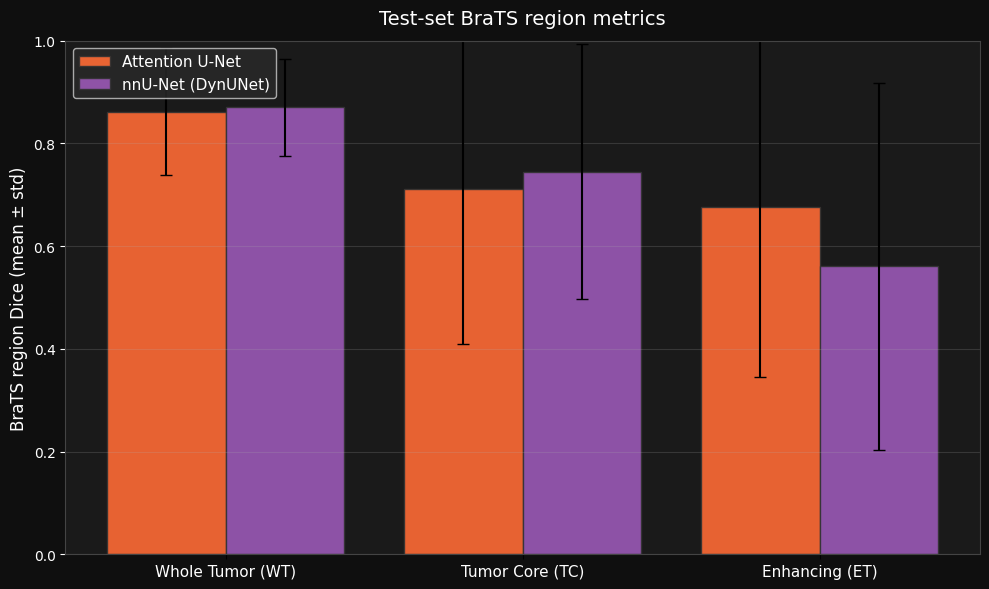

In [7]:
if not test_results:
    print('No test results to plot.')
else:
    regions = ['WT', 'TC', 'ET']
    n_models = len(test_results)
    x = np.arange(len(regions))
    bar_width = 0.8 / n_models

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#0f0f0f')
    ax.set_facecolor('#1a1a1a')

    for i, (name, res) in enumerate(test_results.items()):
        brats = res.get('brats_regions', {})
        values = [brats.get(f'{r}_mean', 0) for r in regions]
        errors = [brats.get(f'{r}_std',  0) for r in regions]
        offset = (i - n_models / 2 + 0.5) * bar_width
        ax.bar(x + offset, values, bar_width,
                yerr=errors, capsize=4,
                color=MODEL_COLORS[name],
                label=MODEL_DISPLAY[name],
                alpha=0.9, edgecolor='#333')

    ax.set_xticks(x)
    ax.set_xticklabels(
        ['Whole Tumor (WT)', 'Tumor Core (TC)', 'Enhancing (ET)'],
        color='white', fontsize=11)
    ax.set_ylabel('BraTS region Dice (mean ± std)', color='white', fontsize=12)
    ax.set_title('Test-set BraTS region metrics',
                  color='white', fontsize=14, pad=12)
    ax.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=11)
    ax.tick_params(axis='y', colors='white')
    ax.grid(alpha=0.2, axis='y')
    ax.set_ylim(0, 1)
    for s in ax.spines.values():
        s.set_edgecolor('#444')

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'comparison_brats_regions.png', dpi=150,
                 bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()

## 8. Summary table — paste straight into the project report

In [8]:
print('=' * 90)
print(f'{"MODEL":<22}{"Params":<10}{"Best val Dice":<16}{"Best epoch":<14}{"Test mean":<12}{"WT / TC / ET":<20}')
print('=' * 90)

for name in ['attention_unet', 'swin_unetr', 'nnunet']:
    display = MODEL_DISPLAY[name]
    hist = histories.get(name)
    test = test_results.get(name)

    if hist:
        best_val = f'{hist["best_dice"]:.4f}'
        best_ep  = str(hist["best_epoch"])
    else:
        best_val, best_ep = '—', '—'

    if test:
        test_mean = f'{test["overall_mean_dice"]:.4f}'
        br = test['brats_regions']
        brats_str = f'{br["WT_mean"]:.3f}/{br["TC_mean"]:.3f}/{br["ET_mean"]:.3f}'
    else:
        test_mean, brats_str = '—', '—'

    # Hardcoded params (could be loaded dynamically)
    params_map = {'attention_unet': '23.6M', 'swin_unetr': '62.2M', 'nnunet': '31.4M'}
    params = params_map.get(name, '—')

    print(f'{display:<22}{params:<10}{best_val:<16}{best_ep:<14}{test_mean:<12}{brats_str:<20}')

print('=' * 90)

# Also save as JSON for later use
summary = {
    name: {
        'best_val_dice': histories.get(name, {}).get('best_dice'),
        'best_epoch'   : histories.get(name, {}).get('best_epoch'),
        'test_mean_dice': test_results.get(name, {}).get('overall_mean_dice'),
        'brats_regions': test_results.get(name, {}).get('brats_regions', {}),
    }
    for name in ['attention_unet', 'swin_unetr', 'nnunet']
}
with open(OUTPUTS_DIR / 'comparison_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(f'\nSaved summary: {OUTPUTS_DIR / "comparison_summary.json"}')

MODEL                 Params    Best val Dice   Best epoch    Test mean   WT / TC / ET        
Attention U-Net       23.6M     0.7642          35            0.7308      0.862/0.711/0.676   
SwinUNETR             62.2M     0.8219          75            —           —                   
nnU-Net (DynUNet)     31.4M     0.7562          80            0.6925      0.870/0.745/0.560   

Saved summary: D:\2_ML PROJECTS\30. Brainstorm\CranioVision\outputs\comparison_summary.json
